## Step 1: Install Libraries

In [28]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [27]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\archive (7)\smart_logistics_dataset.csv")

In [29]:
# Basic statistics

print("Statistical Summary:")
print(df.describe())


Statistical Summary:
          Latitude    Longitude  Inventory_Level  Temperature     Humidity  \
count  1000.000000  1000.000000      1000.000000  1000.000000  1000.000000   
mean     -1.360093     0.837049       297.915000    23.893900    65.042200   
std      51.997183   104.843618       113.554773     3.322178     8.753765   
min     -89.791500  -179.820200       100.000000    18.000000    50.000000   
25%     -46.167975   -88.448075       201.000000    21.200000    57.200000   
50%      -4.503150     0.678300       299.000000    23.800000    65.200000   
75%      44.502800    88.156450       399.000000    26.600000    72.400000   
max      89.870100   179.923700       500.000000    30.000000    80.000000   

       Waiting_Time  User_Transaction_Amount  User_Purchase_Frequency  \
count   1000.000000              1000.000000              1000.000000   
mean      35.062000               299.055000                 5.513000   
std       14.477768               117.787792             

In [30]:


# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check for duplicates
print("\nDuplicate Rows:", df.duplicated().sum())


Missing Values:
Timestamp                    0
Asset_ID                     0
Latitude                     0
Longitude                    0
Inventory_Level              0
Shipment_Status              0
Temperature                  0
Humidity                     0
Traffic_Status               0
Waiting_Time                 0
User_Transaction_Amount      0
User_Purchase_Frequency      0
Logistics_Delay_Reason     263
Asset_Utilization            0
Demand_Forecast              0
Logistics_Delay              0
dtype: int64

Duplicate Rows: 0


In [31]:
# Remove duplicates
df_clean = df.drop_duplicates()
print(f"Removed {len(df) - len(df_clean)} duplicate rows")

# Handle missing values
# For numeric columns: fill with median
numeric_cols = df_clean.select_dtypes(include=['number']).columns
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# For object/text columns: fill with 'Unknown'
object_cols = df_clean.select_dtypes(include=['object']).columns
for col in object_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna('Unknown', inplace=True)

print(f"\nAfter cleaning - Missing values: {df_clean.isnull().sum().sum()}")
print(" Data cleaning completed")

Removed 0 duplicate rows

After cleaning - Missing values: 0
 Data cleaning completed


## Step 8: Encode Categorical Columns

In [47]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nTest target distribution:")
print(y_test.value_counts())

Training set: 800 samples
Test set: 200 samples

Training target distribution:
Logistics_Delay
1    453
0    347
Name: count, dtype: int64

Test target distribution:
Logistics_Delay
1    113
0     87
Name: count, dtype: int64


In [50]:
# Function to calculate metrics
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    }

# Evaluate both models
results_lr = evaluate_model(y_test, y_pred_lr, 'Logistic Regression')
results_rf = evaluate_model(y_test, y_pred_rf, 'Random Forest')

# Create comparison table
results_df = pd.DataFrame([results_lr, results_rf])
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(results_df.to_string(index=False))
print("="*60)

# Find best model
best_model_name = results_df.loc[results_df['F1 Score'].idxmax(), 'Model']
print(f"Best Model: {best_model_name} (based on F1 Score)")


MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1 Score
Logistic Regression     0.885   0.840909 0.982301  0.906122
      Random Forest     1.000   1.000000 1.000000  1.000000
Best Model: Random Forest (based on F1 Score)


## Step 16: Save the Best Model

In [52]:

print(f"\nDataset Info:")
print(f"  - Original rows: {len(df)}")
print(f"  - After cleaning: {len(df_no_outliers)}")
print(f"  - Number of features: {X_scaled.shape[1]}")
print(f"  - Training samples: {len(X_train)}")
print(f"  - Test samples: {len(X_test)}")

print(f"\nBest Model: {best_model_name}")
print(f"  - Accuracy:  {results_df[results_df['Model']==best_model_name]['Accuracy'].values[0]:.4f}")
print(f"  - Precision: {results_df[results_df['Model']==best_model_name]['Precision'].values[0]:.4f}")
print(f"  - Recall:    {results_df[results_df['Model']==best_model_name]['Recall'].values[0]:.4f}")
print(f"  - F1 Score:  {results_df[results_df['Model']==best_model_name]['F1 Score'].values[0]:.4f}")

print(f"\nSaved Files:")
print(f"  - Model: best_logistics_model.pkl")
print(f"  - Scaler: feature_scaler.pkl")
print(f"  - Encoders: label_encoders.pkl")

print(f"\nNext Steps:")
print(f"  1. Try different models or hyperparameters")
print(f"  2. Use the model to predict on new data")
print(f"  3. Deploy the model to production")
print(f"  4. Monitor model performance over time")



Dataset Info:
  - Original rows: 1000
  - After cleaning: 1000
  - Number of features: 14
  - Training samples: 800
  - Test samples: 200

Best Model: Random Forest
  - Accuracy:  1.0000
  - Precision: 1.0000
  - Recall:    1.0000
  - F1 Score:  1.0000

Saved Files:
  - Model: best_logistics_model.pkl
  - Scaler: feature_scaler.pkl
  - Encoders: label_encoders.pkl

Next Steps:
  1. Try different models or hyperparameters
  2. Use the model to predict on new data
  3. Deploy the model to production
  4. Monitor model performance over time


## Step 18: Summary & Next Steps

In [54]:
# Load the saved model
loaded_model = joblib.load('best_logistics_model.pkl')
print(" Model loaded successfully\n")

# Make predictions on first 10 test samples
sample_predictions = loaded_model.predict(X_test.head(10))
sample_probabilities = loaded_model.predict_proba(X_test.head(10))

# Create results dataframe
prediction_results = pd.DataFrame({
    'Actual Delay': y_test.head(10).values,
    'Predicted Delay': sample_predictions,
    'Prob (No Delay)': sample_probabilities[:, 0].round(4),
    'Prob (Delay)': sample_probabilities[:, 1].round(4),
    'Prediction': ['Delay' if p == 1 else 'No Delay' for p in sample_predictions],
    'Correct': (y_test.head(10).values == sample_predictions)
})

print("SAMPLE PREDICTIONS ON TEST DATA")
print(prediction_results.to_string(index=False))


accuracy_sample = (prediction_results['Correct'].sum() / len(prediction_results)) * 100
print(f"\nAccuracy on these 10 samples: {accuracy_sample:.1f}%")
print(f"\nPredictions completed!")

 Model loaded successfully

SAMPLE PREDICTIONS ON TEST DATA
 Actual Delay  Predicted Delay  Prob (No Delay)  Prob (Delay) Prediction  Correct
            0                0             0.86          0.14   No Delay     True
            0                0             0.92          0.08   No Delay     True
            1                1             0.01          0.99      Delay     True
            1                1             0.02          0.98      Delay     True
            0                0             0.87          0.13   No Delay     True
            0                0             0.90          0.10   No Delay     True
            1                1             0.01          0.99      Delay     True
            0                0             0.90          0.10   No Delay     True
            0                0             0.93          0.07   No Delay     True
            1                1             0.04          0.96      Delay     True

Accuracy on these 10 samples: 100.0%


## Step 17: Make Sample Predictions

In [55]:
# Select best model
best_model = rf_model if best_model_name == 'Random Forest' else lr_model

# Save the model
model_filename = 'best_logistics_model.pkl'
joblib.dump(best_model, model_filename)
print(f"Model saved as '{model_filename}'")

# Also save the scaler for preprocessing new data
scaler_filename = 'feature_scaler.pkl'
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved as '{scaler_filename}'")

# Save encoders
encoders_filename = 'label_encoders.pkl'
joblib.dump(label_encoders, encoders_filename)
print(f" Encoders saved as '{encoders_filename}'")

Model saved as 'best_logistics_model.pkl'
Scaler saved as 'feature_scaler.pkl'
 Encoders saved as 'label_encoders.pkl'



Top 10 Most Important Features:
                Feature  Importance
        Shipment_Status    0.417821
         Traffic_Status    0.363405
               Latitude    0.025473
              Longitude    0.024111
        Inventory_Level    0.022414
           Waiting_Time    0.022327
      Asset_Utilization    0.020612
User_Transaction_Amount    0.020415
               Humidity    0.019920
            Temperature    0.019831


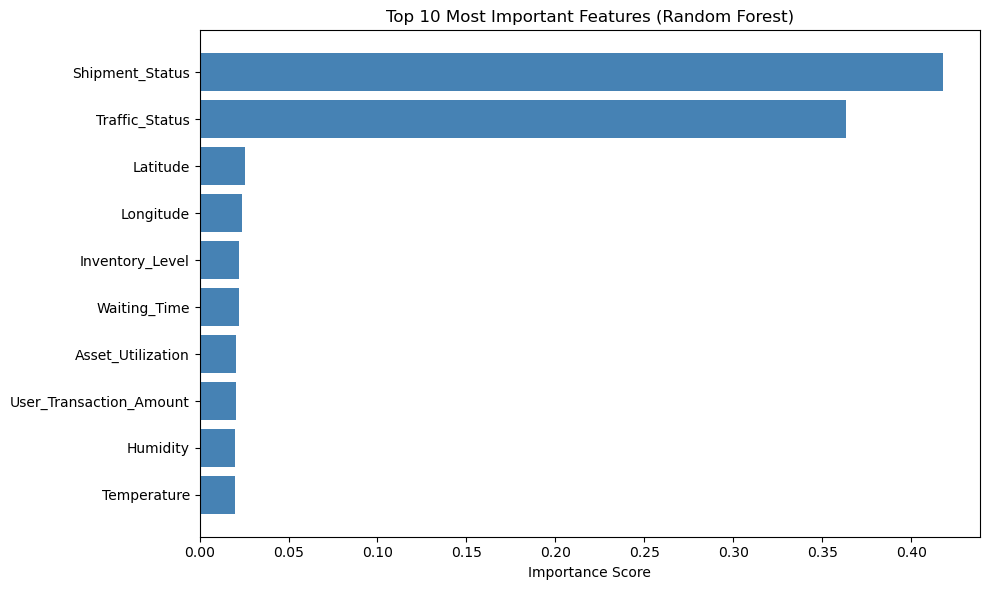

✓ Feature importance plotted


In [43]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Plot top 10 features
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'].head(10), feature_importance['Importance'].head(10), color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print("✓ Feature importance plotted")

## Step 15: Feature Importance (Random Forest)

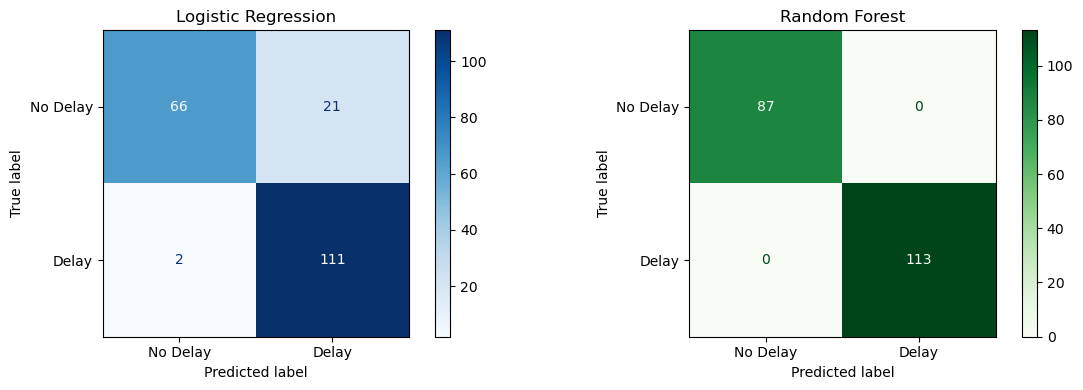

✓ Confusion matrices displayed


In [42]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['No Delay', 'Delay']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression')

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['No Delay', 'Delay']).plot(ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()
print("✓ Confusion matrices displayed")

## Step 13: Evaluate Models

In [40]:
# Make predictions on test set
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

print("Predictions made on test set")
print(f"\nLogistic Regression predictions (first 10): {y_pred_lr[:10]}")
print(f"Random Forest predictions (first 10): {y_pred_rf[:10]}")

Predictions made on test set

Logistic Regression predictions (first 10): [0 0 1 1 0 0 1 1 0 1]
Random Forest predictions (first 10): [0 0 1 1 0 0 1 0 0 1]


## Step 12: Make Predictions

In [ ]:
# Model 1: Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
print(" Logistic Regression trained")

# Model 2: Random Forest
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print(" Random Forest trained")

Training Logistic Regression...
✓ Logistic Regression trained

Training Random Forest...
✓ Random Forest trained


## Step 11: Train Models

In [36]:
# Scale all features to 0-1 range
# This helps models train faster and perform better
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
X_scaled = pd.DataFrame(X_scaled, columns=X_encoded.columns)

print("Feature scaling completed")
print(f"\nScaled data statistics:")
print(X_scaled.describe())
print(" Feature scaling done")

Feature scaling completed

Scaled data statistics:
           Asset_ID      Latitude     Longitude  Inventory_Level  \
count  1.000000e+03  1.000000e+03  1.000000e+03     1.000000e+03   
mean   3.552714e-17  2.664535e-17 -2.753353e-17    -1.723066e-16   
std    1.000500e+00  1.000500e+00  1.000500e+00     1.000500e+00   
min   -1.593094e+00 -1.701547e+00 -1.723974e+00    -1.743776e+00   
25%   -8.908265e-01 -8.621679e-01 -8.520290e-01    -8.538918e-01   
50%    1.625750e-01 -6.047693e-02 -1.514907e-03     9.559641e-03   
75%    8.648426e-01  8.824678e-01  8.332705e-01     8.906326e-01   
max    1.567110e+00  1.755400e+00  1.708986e+00     1.780516e+00   

       Shipment_Status   Temperature      Humidity  Traffic_Status  \
count     1.000000e+03  1.000000e+03  1.000000e+03    1.000000e+03   
mean      9.592327e-17  4.227729e-16  6.590284e-16   -2.131628e-17   
std       1.000500e+00  1.000500e+00  1.000500e+00    1.000500e+00   
min      -1.183642e+00 -1.774995e+00 -1.719229e+00   -1.

## Step 10: Split Data into Train and Test

In [34]:
# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

# Create a copy for encoding
X_encoded = X.copy()

# Encode each categorical column using LabelEncoder
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    label_encoders[col] = le
    print(f"Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nAll columns encoded: {X_encoded.dtypes.unique()}")
print(" Categorical encoding completed")

Categorical columns: ['Asset_ID', 'Shipment_Status', 'Traffic_Status', 'Logistics_Delay_Reason']
Encoded 'Asset_ID': {'Truck_1': np.int64(0), 'Truck_10': np.int64(1), 'Truck_2': np.int64(2), 'Truck_3': np.int64(3), 'Truck_4': np.int64(4), 'Truck_5': np.int64(5), 'Truck_6': np.int64(6), 'Truck_7': np.int64(7), 'Truck_8': np.int64(8), 'Truck_9': np.int64(9)}
Encoded 'Shipment_Status': {'Delayed': np.int64(0), 'Delivered': np.int64(1), 'In Transit': np.int64(2)}
Encoded 'Traffic_Status': {'Clear': np.int64(0), 'Detour': np.int64(1), 'Heavy': np.int64(2)}
Encoded 'Logistics_Delay_Reason': {'Mechanical Failure': np.int64(0), 'Traffic': np.int64(1), 'Unknown': np.int64(2), 'Weather': np.int64(3)}

All columns encoded: [dtype('int64') dtype('float64')]
 Categorical encoding completed


In [35]:
# Scale all features to 0-1 range
# This helps models train faster and perform better
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
X_scaled = pd.DataFrame(X_scaled, columns=X_encoded.columns)

print("Feature scaling completed")
print(f"\nScaled data statistics:")
print(X_scaled.describe())
print("✓ Feature scaling done")

Feature scaling completed

Scaled data statistics:
           Asset_ID      Latitude     Longitude  Inventory_Level  \
count  1.000000e+03  1.000000e+03  1.000000e+03     1.000000e+03   
mean   3.552714e-17  2.664535e-17 -2.753353e-17    -1.723066e-16   
std    1.000500e+00  1.000500e+00  1.000500e+00     1.000500e+00   
min   -1.593094e+00 -1.701547e+00 -1.723974e+00    -1.743776e+00   
25%   -8.908265e-01 -8.621679e-01 -8.520290e-01    -8.538918e-01   
50%    1.625750e-01 -6.047693e-02 -1.514907e-03     9.559641e-03   
75%    8.648426e-01  8.824678e-01  8.332705e-01     8.906326e-01   
max    1.567110e+00  1.755400e+00  1.708986e+00     1.780516e+00   

       Shipment_Status   Temperature      Humidity  Traffic_Status  \
count     1.000000e+03  1.000000e+03  1.000000e+03    1.000000e+03   
mean      9.592327e-17  4.227729e-16  6.590284e-16   -2.131628e-17   
std       1.000500e+00  1.000500e+00  1.000500e+00    1.000500e+00   
min      -1.183642e+00 -1.774995e+00 -1.719229e+00   -1.

In [38]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nTest target distribution:")
print(y_test.value_counts())

Training set: 800 samples
Test set: 200 samples

Training target distribution:
Logistics_Delay
1    453
0    347
Name: count, dtype: int64

Test target distribution:
Logistics_Delay
1    113
0     87
Name: count, dtype: int64


## Step 10: Split Data into Train and Test

## Step 9: Scale Features

In [33]:
# Separate target from features
X = df_no_outliers.drop(['Logistics_Delay', 'Timestamp'], axis=1)  # Remove target and timestamp
y = df_no_outliers['Logistics_Delay']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

Features shape: (1000, 14)
Target shape: (1000,)

Feature columns: ['Asset_ID', 'Latitude', 'Longitude', 'Inventory_Level', 'Shipment_Status', 'Temperature', 'Humidity', 'Traffic_Status', 'Waiting_Time', 'User_Transaction_Amount', 'User_Purchase_Frequency', 'Logistics_Delay_Reason', 'Asset_Utilization', 'Demand_Forecast']


## Step 7: Prepare Features for Model

In [32]:
# Remove extreme outliers using IQR method
# Keeps most data, removes only extreme values
df_no_outliers = df_clean.copy()
outliers_removed = 0

for col in numeric_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Keep data within reasonable bounds
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    
    before = len(df_no_outliers)
    df_no_outliers = df_no_outliers[(df_no_outliers[col] >= lower_bound) & 
                                     (df_no_outliers[col] <= upper_bound)]
    outliers_removed += before - len(df_no_outliers)

print(f"Outliers removed: {outliers_removed} rows")
print(f"Remaining data: {len(df_no_outliers)} rows")
print(" Outlier handling completed")

Outliers removed: 0 rows
Remaining data: 1000 rows
✓ Outlier handling completed


## Step 6: Handle Outliers (Simple Method)

## Step 5: Data Cleaning

In [ ]:
# Visualize the target distribution
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df['Logistics_Delay'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Logistics Delay Distribution')
plt.xlabel('Delay (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df['Logistics_Delay'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['green', 'red'])
plt.title('Logistics Delay Percentage')
plt.ylabel('')

plt.tight_layout()
plt.show()
print(" Target distribution visualized")

## Step 4: Exploratory Data Analysis (EDA)

In [ ]:
# Load the dataset
df = pd.read_csv('smart_logistics_dataset.csv')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn Names and Types:")
print(df.dtypes)
print("\nTarget Column Distribution:")
print(df['Logistics_Delay'].value_counts())

Dataset Shape: (1000, 16)

First 5 rows:
             Timestamp  Asset_ID  Latitude  Longitude  Inventory_Level  \
0  2024-03-20 00:11:14   Truck_7  -65.7383    11.2497              390   
1  2024-10-30 07:53:51   Truck_6   22.2748  -131.7086              491   
2  2024-07-29 18:42:48  Truck_10   54.9232    79.5455              190   
3  2024-10-28 00:50:54   Truck_9   42.3900    -1.4788              330   
4  2024-09-27 15:52:58   Truck_7  -65.8477    47.9468              480   

  Shipment_Status  Temperature  Humidity Traffic_Status  Waiting_Time  \
0         Delayed         27.0      67.8         Detour            38   
1      In Transit         22.5      54.3          Heavy            16   
2      In Transit         25.2      62.2         Detour            34   
3       Delivered         25.4      52.3          Heavy            37   
4         Delayed         20.5      57.2          Clear            56   

   User_Transaction_Amount  User_Purchase_Frequency Logistics_Delay_Reason 

## Step 3: Load and Inspect Data

## Step 2: Import Libraries

In [ ]:
# Install required packages
!pip install -q pandas numpy matplotlib seaborn scikit-learn joblib